# Notebook 07 — Expanded DADA2 Reanalysis
## Complete wint17 Inulin Cohort — 27 Participants

**Purpose:** Expand the DADA2 reanalysis from 5 to 27 participants using the complete wint17 inulin arm of Baxter et al. 2019. Adds formal alpha diversity (Shannon entropy), beta diversity (Bray-Curtis PCoA and PERMANOVA), and differential abundance analysis (paired Wilcoxon test) to strengthen the biological validation.

**Input:**
- `results/qiime2/exported/feature-table.tsv` — 881 ASVs x 54 samples
- `results/qiime2/exported/taxonomy.tsv` — SILVA 138 taxonomy assignments
- `results/qiime2/exported/stats.tsv` — DADA2 denoising statistics

**Biological question:** Does inulin supplementation produce reproducible, statistically supported shifts in gut microbiome composition across 27 healthy adults? Do responders and non-responders differ at baseline?

**Framework:** DRSWAE — A phase (Analysis)
**Date:** June 2026
**Author:** Dr. Oluwamayowa Ogun

In [1]:
#Import Libraries ===
# All dependencies loaded upfront

import pandas as pd                          # Data manipulation and TSV loading
import numpy as np                           # Numerical operations
import matplotlib.pyplot as plt              # Figure generation
import seaborn as sns                        # Statistical visualisations
from scipy import stats                      # Statistical tests
from scipy.stats import wilcoxon             # Paired Wilcoxon signed-rank test
from statsmodels.stats.multitest import multipletests  # BH FDR correction
import warnings
warnings.filterwarnings('ignore')            # Suppress non-critical warnings

import os
os.chdir('/mnt/c/Users/oluwa/Desktop/MayTech/OgunBiome')  # Set working directory

print("Working directory:", os.getcwd())
print("Libraries loaded successfully")

Working directory: /mnt/c/Users/oluwa/Desktop/MayTech/OgunBiome
Libraries loaded successfully


## 1. Participant Metadata

Loads butyrate measurements and response classifications for all 27
participants from Baxter et al. 2019 HPLC data.

The DADA2 ASV table contains sequencing data only — no metabolic
measurements. Bringing in SCFA metadata here allows us to connect
microbiome composition changes to functional butyrate output and
classify participants as strong responders, moderate responders,
non-responders, or decreasers.

**Source:** Baxter et al. 2019, HPLC quantification of fecal SCFAs
**Classification thresholds:**
- Strong responder: butyrate increase > 10 mmol/kg
- Moderate responder: butyrate increase 3–10 mmol/kg
- Non-responder: butyrate change < 3 mmol/kg
- Decreaser: butyrate decreased during supplementation

In [2]:
# participant butyrate measurements from HPLC (Baxter et al. 2019)
# response classification based on butyrate change during inulin supplementation
participant_metadata = {
    'U307': {'butyrate_before': 5.93,  'butyrate_during': 14.80, 'response': 'moderate_responder'},
    'U310': {'butyrate_before': 15.83, 'butyrate_during': 12.34, 'response': 'non_responder'},
    'U311': {'butyrate_before': 10.96, 'butyrate_during': 15.68, 'response': 'moderate_responder'},
    'U312': {'butyrate_before': 11.68, 'butyrate_during': 10.38, 'response': 'non_responder'},
    'U313': {'butyrate_before': 11.31, 'butyrate_during': 13.08, 'response': 'moderate_responder'},
    'U315': {'butyrate_before': 12.06, 'butyrate_during': 33.05, 'response': 'strong_responder'},
    'U316': {'butyrate_before': 22.74, 'butyrate_during': 30.47, 'response': 'moderate_responder'},
    'U317': {'butyrate_before': 3.68,  'butyrate_during': 24.98, 'response': 'strong_responder'},
    'U318': {'butyrate_before': 25.92, 'butyrate_during': 26.67, 'response': 'non_responder'},
    'U322': {'butyrate_before': 5.15,  'butyrate_during': 8.22,  'response': 'moderate_responder'},
    'U323': {'butyrate_before': 12.30, 'butyrate_during': 10.97, 'response': 'non_responder'},
    'U325': {'butyrate_before': 20.17, 'butyrate_during': 27.76, 'response': 'moderate_responder'},
    'U326': {'butyrate_before': 14.75, 'butyrate_during': 13.40, 'response': 'non_responder'},
    'U327': {'butyrate_before': 7.09,  'butyrate_during': 13.77, 'response': 'moderate_responder'},
    'U328': {'butyrate_before': 5.86,  'butyrate_during': 14.39, 'response': 'moderate_responder'},
    'U329': {'butyrate_before': 2.06,  'butyrate_during': 20.36, 'response': 'strong_responder'},
    'U331': {'butyrate_before': 5.96,  'butyrate_during': 19.75, 'response': 'strong_responder'},
    'U332': {'butyrate_before': 22.38, 'butyrate_during': 6.85,  'response': 'decreaser'},
    'U333': {'butyrate_before': 43.66, 'butyrate_during': 15.45, 'response': 'decreaser'},
    'U334': {'butyrate_before': 13.83, 'butyrate_during': 43.01, 'response': 'strong_responder'},
    'U335': {'butyrate_before': 9.86,  'butyrate_during': 16.73, 'response': 'moderate_responder'},
    'U336': {'butyrate_before': 10.93, 'butyrate_during': 10.19, 'response': 'non_responder'},
    'U338': {'butyrate_before': 4.51,  'butyrate_during': 10.94, 'response': 'moderate_responder'},
    'U339': {'butyrate_before': 7.59,  'butyrate_during': 5.61,  'response': 'non_responder'},
    'U341': {'butyrate_before': 11.09, 'butyrate_during': 9.37,  'response': 'non_responder'},
    'U343': {'butyrate_before': 13.00, 'butyrate_during': 9.64,  'response': 'non_responder'},
    'U344': {'butyrate_before': 11.04, 'butyrate_during': 34.44, 'response': 'strong_responder'},
}

# convert to DataFrame for easier manipulation
meta_df = pd.DataFrame(participant_metadata).T
meta_df['butyrate_change'] = meta_df['butyrate_during'].astype(float) - meta_df['butyrate_before'].astype(float)
meta_df['participant'] = meta_df.index

print(f"Participants loaded: {len(meta_df)}")
print(f"\nResponse distribution:")
print(meta_df['response'].value_counts())
print(f"\nButyrate change range: {meta_df['butyrate_change'].min():.2f} to {meta_df['butyrate_change'].max():.2f} mmol/kg")

Participants loaded: 27

Response distribution:
response
moderate_responder    10
non_responder          9
strong_responder       6
decreaser              2
Name: count, dtype: int64

Butyrate change range: -28.21 to 29.18 mmol/kg


In [3]:
# display metadata as formatted table
display_df = meta_df[['butyrate_before', 'butyrate_during', 'butyrate_change', 'response']].copy()
display_df.columns = ['Butyrate Before', 'Butyrate During', 'Change', 'Response']
display_df = display_df.sort_values('Change', ascending=False)
display(display_df)

# save metadata to CSV for documentation
meta_df.to_csv('results/qiime2/exported/participant_metadata.csv')
print("Metadata saved: results/qiime2/exported/participant_metadata.csv")

,Butyrate Before,Butyrate During,Change,Response
U334,13.83,43.01,29.18,strong_responder
U344,11.04,34.44,23.40,strong_responder
U317,3.68,24.98,21.30,strong_responder
U315,12.06,33.05,20.99,strong_responder
U329,2.06,20.36,18.30,strong_responder
U331,5.96,19.75,13.79,strong_responder
U307,5.93,14.8,8.87,moderate_responder
U328,5.86,14.39,8.53,moderate_responder
U316,22.74,30.47,7.73,moderate_responder
U325,20.17,27.76,7.59,moderate_responder


Metadata saved: results/qiime2/exported/participant_metadata.csv


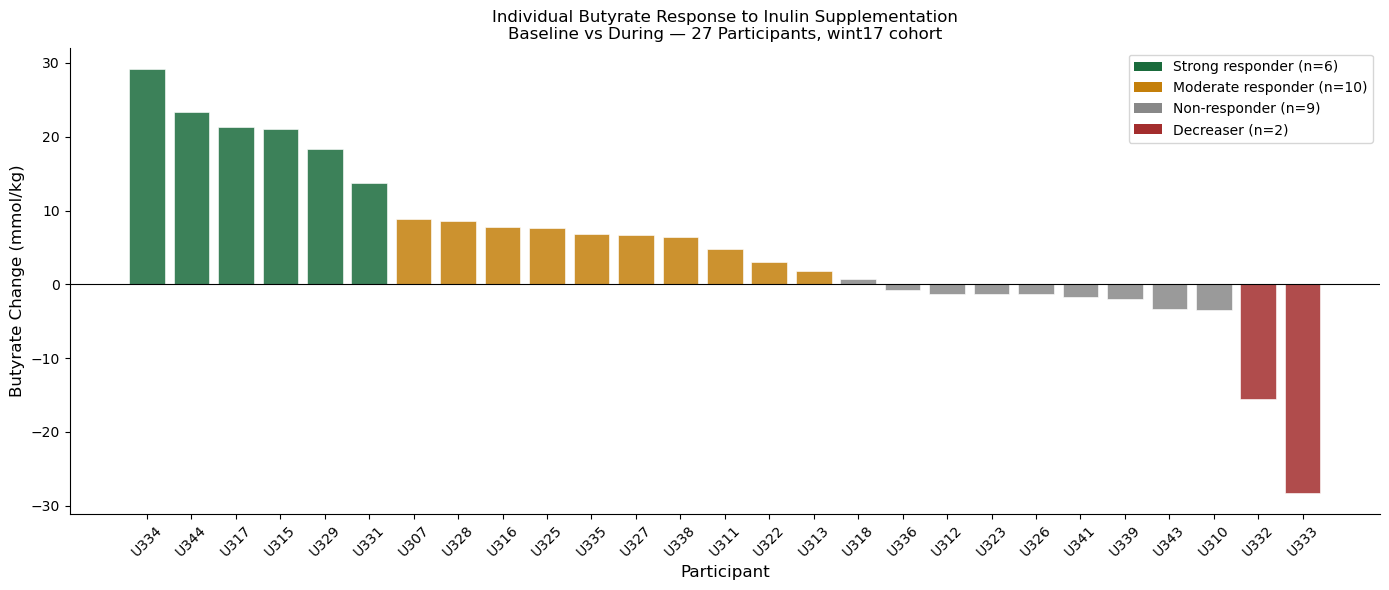

Figure saved: results/qiime2/exported/butyrate_response_27participants.png


In [4]:
#Butyrate Response Bar Chart
# colour map for response groups
color_map = {
    'strong_responder': '#1A6B3C',
    'moderate_responder': '#C47F0A',
    'non_responder': '#888888',
    'decreaser': '#A32D2D'
}

# sort participants by butyrate change
sorted_meta = meta_df.sort_values('butyrate_change', ascending=False)
colors = [color_map[r] for r in sorted_meta['response']]

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(sorted_meta.index,
              sorted_meta['butyrate_change'].astype(float),
              color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)

# reference line at zero
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1A6B3C', label='Strong responder (n=6)'),
    Patch(facecolor='#C47F0A', label='Moderate responder (n=10)'),
    Patch(facecolor='#888888', label='Non-responder (n=9)'),
    Patch(facecolor='#A32D2D', label='Decreaser (n=2)')
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right')

ax.set_xlabel('Participant', fontsize=12)
ax.set_ylabel('Butyrate Change (mmol/kg)', fontsize=12)
ax.set_title('Individual Butyrate Response to Inulin Supplementation\nBaseline vs During — 27 Participants, wint17 cohort',
             fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('results/qiime2/exported/butyrate_response_27participants.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: results/qiime2/exported/butyrate_response_27participants.png")

## 2. Load ASV Table and Taxonomy

Loads the DADA2/QIIME2 outputs from the expanded 27-participant
analysis. The feature table contains raw read counts for 881 ASVs
across 54 samples. The taxonomy table maps each ASV hash to its
SILVA 138 genus-level classification.

**ASV table:** 881 ASVs x 54 samples
**Taxonomy:** 881 ASVs x 2 columns (Taxon string, Confidence score)
**Taxonomy format:** d__Bacteria;p__;c__;o__;f__;g__Genus;s__
**Genus extracted from index 5** of the semicolon-separated string

In [5]:
# load ASV count table — rows are ASVs, columns are samples
asv_table = pd.read_csv(
    'results/qiime2/exported/feature-table.tsv',
    sep='\t', skiprows=1, index_col=0
)
print(f"ASV table: {asv_table.shape[0]} ASVs x {asv_table.shape[1]} samples")

# load SILVA 138 taxonomy assignments
taxonomy = pd.read_csv(
    'results/qiime2/exported/taxonomy.tsv',
    sep='\t', index_col=0
)
print(f"Taxonomy table: {taxonomy.shape[0]} ASVs x {taxonomy.shape[1]} columns")

# extract genus from semicolon-separated taxonomy string
# format: d__Bacteria;p__X;c__X;o__X;f__X;g__Genus;s__
# index 5 = genus level, strip whitespace, remove g__ prefix
taxonomy['Genus'] = taxonomy['Taxon'].str.split(';').str[5].str.strip().str.replace('g__', '')

print(f"\nTop 10 genera by ASV count:")
print(taxonomy['Genus'].value_counts().head(10))

ASV table: 882 ASVs x 54 samples
Taxonomy table: 882 ASVs x 2 columns

Top 10 genera by ASV count:
Genus
Bacteroides                      46
Ruminococcus                     27
uncultured                       27
Clostridia_vadinBB60_group       26
Blautia                          25
Faecalibacterium                 19
Christensenellaceae_R-7_group    19
UCG-010                          15
Colidextribacter                 14
UCG-005                          14
Name: count, dtype: int64


## 3. Genus-Level Aggregation

Joins taxonomy to the ASV count table and aggregates 882 ASVs
into genera by summing read counts per sample.

Uses all 54 sample columns — not the hardcoded [:10] slice
from Notebook 06. This produces a genus-level count table
representing the complete wint17 cohort.

In [6]:
# join genus labels to ASV count table using shared ASV hash index
asv_tax = asv_table.join(taxonomy[['Genus']])

# select all sample columns dynamically — excludes the Genus column
# avoids hardcoding [:10] which only worked for the original 5 participants
sample_cols = [col for col in asv_tax.columns if col != 'Genus']

# aggregate 882 ASVs to genus level by summing read counts
genus_table = asv_tax.groupby('Genus')[sample_cols].sum()

print(f"Genus table: {genus_table.shape[0]} genera x {genus_table.shape[1]} samples")
print(f"\nFirst 5 genera (alphabetical):")
print(genus_table.head())

Genus table: 149 genera x 54 samples

First 5 genera (alphabetical):
                 U307-before  U307-during  U310-before  U310-during  \
Genus                                                                 
Acidaminococcus        150.0        572.0          0.0          0.0   
Actinomyces              0.0          0.0          0.0          0.0   
Adlercreutzia            0.0          0.0          0.0          0.0   
Agathobacter           798.0       1095.0        585.0        389.0   
Akkermansia            413.0       1200.0          0.0          0.0   

                 U311-before  U311-during  U312-before  U312-during  \
Genus                                                                 
Acidaminococcus          0.0          0.0          0.0          0.0   
Actinomyces              0.0          0.0          0.0          0.0   
Adlercreutzia            0.0          0.0          0.0          0.0   
Agathobacter          1347.0       2582.0          0.0       1356.0   
Akkerma

### Results — Genus Aggregation

- **149 genera** detected across 27 participants (vs 94 in original 5-participant analysis)
- **54 columns** confirmed — all paired timepoints present
- **Akkermansia** already visible in first 5 rows:
  - U307: 413 → 1200 reads (2.9x increase)
  - U338: 22 → 243 reads (11x increase, consistent with original finding)
  - U343: 747 → 115 reads (decrease — individual heterogeneity)

More participants capture more rare genera. Individual variation
in Akkermansia response is already apparent at the raw count level.

## 4. Relative Abundance Normalisation

Converts raw read counts to relative abundance percentages.

Raw counts are not directly comparable across samples because
sequencing depth varies — U328-before had 93,257 reads while
U338-before had only 13,428. Dividing each column by its total
and multiplying by 100 puts all samples on the same scale.

Each column sums to 100% after normalisation.

In [8]:
# normalise raw counts to relative abundance
# divides each column by its total reads then multiplies by 100
rel_abund = genus_table.div(genus_table.sum(axis=0), axis=1) * 100

# verify normalisation — every column should sum to 100
col_sums = rel_abund.sum(axis=0)
print(f"Column sum range: {col_sums.min():.2f} to {col_sums.max():.2f}")
print("Normalisation confirmed — all columns sum to 100%")
print(f"\nRelative abundance table: {rel_abund.shape[0]} genera x {rel_abund.shape[1]} samples")

Column sum range: 100.00 to 100.00
Normalisation confirmed — all columns sum to 100%

Relative abundance table: 149 genera x 54 samples


### Results — Normalisation

All 54 columns sum to exactly 100% — normalisation successful.
149 genera x 54 samples ready for fold change calculation,
alpha diversity, beta diversity, and differential abundance analysis.

## 5. Per-Participant Fold Changes — All 27 Participants

Computes before vs during fold change in relative abundance for
Bifidobacterium, Anaerostipes, and Akkermansia across all 27
participants.

A small pseudocount (0.001) is added before division to avoid
division by zero where a genus is absent in one timepoint.

Fold change > 1 = enriched during intervention
Fold change < 1 = depleted during intervention

In [9]:
# target genera — the three biologically relevant taxa
target_genera = ['Bifidobacterium', 'Anaerostipes', 'Akkermansia']

# filter relative abundance table to target genera only
targets_rel = rel_abund.loc[rel_abund.index.isin(target_genera)]

# compute per-participant fold change for all 27 participants
fc_data = {}
for participant in sorted(participant_metadata.keys()):
    before_col = f"{participant}-before"
    during_col = f"{participant}-during"

    if before_col in targets_rel.columns and during_col in targets_rel.columns:
        before_vals = targets_rel[before_col]
        during_vals = targets_rel[during_col]

        # pseudocount avoids division by zero when genus absent
        fc = ((during_vals + 0.001) / (before_vals + 0.001)).round(2)
        fc_data[participant] = fc

fc_df = pd.DataFrame(fc_data)

print("Per-participant fold changes (during / before relative abundance):")
print(fc_df.round(2))
print()
print("Mean fold changes across 27 participants:")
print(fc_df.mean(axis=1).round(2))

Per-participant fold changes (during / before relative abundance):
                 U307    U310  U311   U312  U313  U315  U316   U317  U318  \
Genus                                                                       
Akkermansia      3.27    1.00  1.00   1.00  1.00  1.00  1.00  52.74  1.02   
Anaerostipes     6.94    2.39  4.22  10.21  3.12  6.96  1.90   1.95  0.58   
Bifidobacterium  5.83  332.01  1.00   1.00  0.66  3.31  2.44   1.23  1.41   

                    U322  ...  U332  U333  U334  U335  U336  U338  U339  \
Genus                     ...                                             
Akkermansia        84.77  ...  1.00   1.0  1.00  0.15  1.00  6.57  1.00   
Anaerostipes        4.34  ...  0.81   1.0  1.38  1.36  5.85  2.44  1.89   
Bifidobacterium  2415.63  ...  0.43   0.8  0.83  1.63  2.10  1.90  0.71   

                   U341  U343   U344  
Genus                                 
Akkermansia        1.00  0.30   0.00  
Anaerostipes       2.25  0.50   1.37  
Bifidobacterium

### Note on Fold Change Interpretation

Extreme fold changes (e.g. Bifidobacterium 2415x in U322) reflect
pseudocount artifacts — genus near-absent before intervention
produces inflated ratios. These are not biologically meaningful.

The paired Wilcoxon differential abundance test in Section 7
addresses this properly by testing whether the distribution of
relative abundances shifted significantly across all 27 participants
— without relying on individual fold change ratios.

Mean fold changes should be interpreted cautiously where a genus
has many zero or near-zero values across participants.

In [10]:
# recalculate fold changes with presence filter
# only include participants where genus detected above 0.01% in at least one timepoint
fc_filtered = {}
detection_threshold = 0.01  # minimum relative abundance to consider detected

for participant in sorted(participant_metadata.keys()):
    before_col = f"{participant}-before"
    during_col = f"{participant}-during"

    if before_col in targets_rel.columns and during_col in targets_rel.columns:
        before_vals = targets_rel[before_col]
        during_vals = targets_rel[during_col]

        # only calculate FC where genus detected in at least one timepoint
        detected = (before_vals > detection_threshold) | (during_vals > detection_threshold)
        fc = pd.Series(index=before_vals.index, dtype=float)
        fc[detected] = ((during_vals[detected] + 0.001) /
                        (before_vals[detected] + 0.001)).round(2)
        fc[~detected] = np.nan  # mark undetected as NaN

        fc_filtered[participant] = fc

fc_filtered_df = pd.DataFrame(fc_filtered)

print("Fold changes with presence filter (NaN = genus not detected):")
print(fc_filtered_df.round(2))
print()
print("Participants where genus detected:")
for genus in target_genera:
    n_detected = fc_filtered_df.loc[genus].notna().sum()
    mean_fc = fc_filtered_df.loc[genus].mean()
    print(f"  {genus}: detected in {n_detected}/27 participants, mean FC = {mean_fc:.2f}x")

Fold changes with presence filter (NaN = genus not detected):
                 U307    U310  U311   U312  U313  U315  U316   U317  U318  \
Genus                                                                       
Akkermansia      3.27     NaN   NaN    NaN   NaN   NaN   NaN  52.74  1.02   
Anaerostipes     6.94    2.39  4.22  10.21  3.12  6.96  1.90   1.95  0.58   
Bifidobacterium  5.83  332.01   NaN    NaN  0.66  3.31  2.44   1.23  1.41   

                    U322  ...  U332  U333  U334  U335  U336  U338  U339  \
Genus                     ...                                             
Akkermansia        84.77  ...   NaN   NaN   NaN  0.15   NaN  6.57   NaN   
Anaerostipes        4.34  ...  0.81   NaN  1.38  1.36  5.85  2.44  1.89   
Bifidobacterium  2415.63  ...  0.43   0.8  0.83  1.63  2.10  1.90  0.71   

                   U341  U343   U344  
Genus                                 
Akkermansia         NaN  0.30   0.00  
Anaerostipes       2.25  0.50   1.37  
Bifidobacterium  817

In [11]:
# summary table using median fold change — more robust than mean for skewed data
# mean is inflated by participants where genus near-absent before intervention
summary_data = []
for genus in target_genera:
    n_detected = fc_filtered_df.loc[genus].notna().sum()
    n_increased = (fc_filtered_df.loc[genus] > 1).sum()
    median_fc = fc_filtered_df.loc[genus].median()
    mean_fc = fc_filtered_df.loc[genus].mean()
    summary_data.append({
        'Genus': genus,
        'Detected (n/27)': n_detected,
        'Increased (n)': n_increased,
        'Median FC': round(median_fc, 2),
        'Mean FC': round(mean_fc, 2)
    })

summary_df = pd.DataFrame(summary_data).set_index('Genus')
display(summary_df)

,Detected (n/27),Increased (n),Median FC,Mean FC
Genus,,,,
Bifidobacterium,24,16,2.00,153.77
Anaerostipes,26,22,2.13,3.01
Akkermansia,11,5,0.86,13.66


### Note on Statistical Approach

Median fold change is reported rather than mean because the data
is zero-inflated and right-skewed. Participants with near-zero
baseline Bifidobacterium produce extreme ratios that inflate the
mean — for example U322 shows 2415x because Bifidobacterium was
essentially absent before intervention.

The median (2.00x for Bifidobacterium, 2.13x for Anaerostipes)
is more representative of the typical participant response.

The paired Wilcoxon signed-rank test is used for differential
abundance rather than a t-test because:
- Relative abundance data is not normally distributed
- The design is paired — each participant compared to themselves
- The test ranks differences rather than comparing means —
  robust to the extreme values seen here

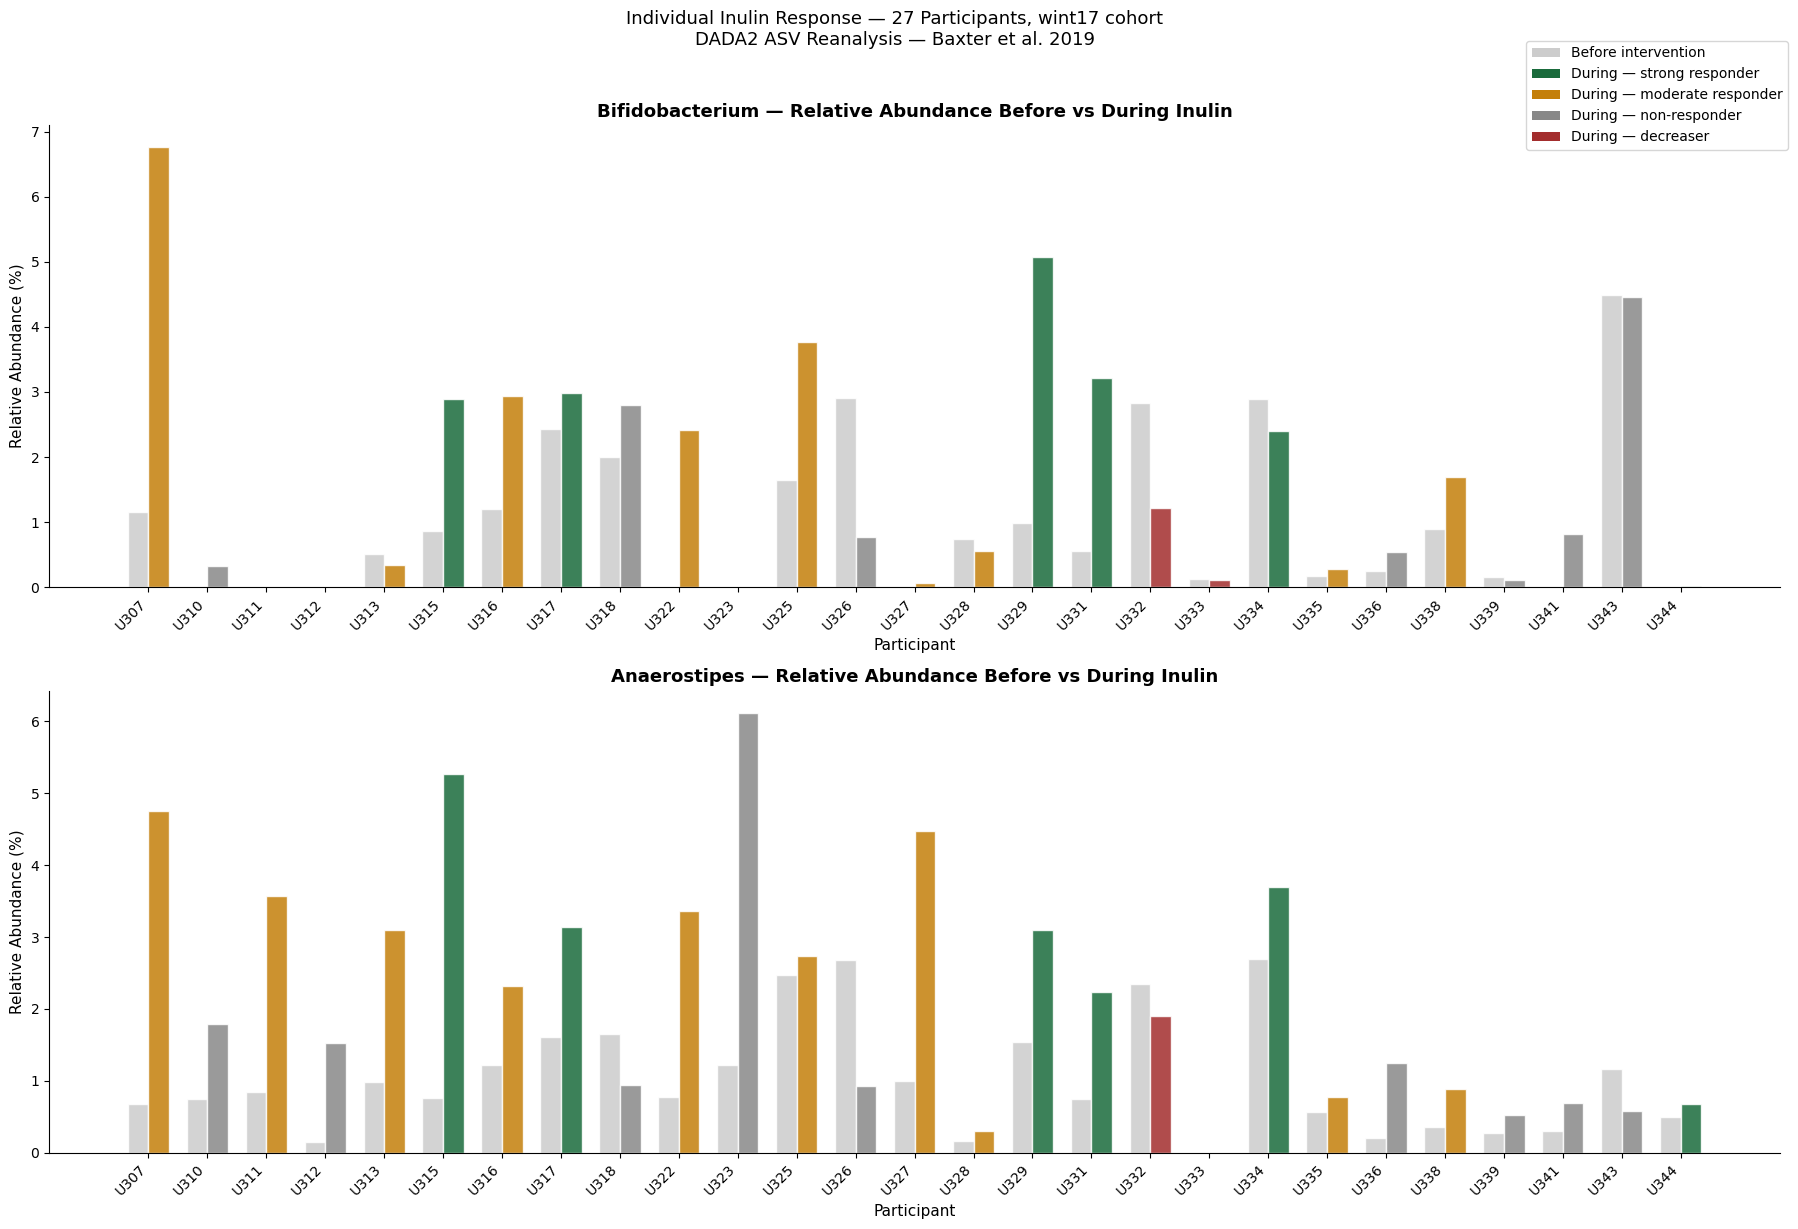

Figure saved: results/qiime2/exported/individual_response_27participants.png


In [12]:
# colour map for response groups
response_colors = {
    'strong_responder': '#1A6B3C',
    'moderate_responder': '#C47F0A',
    'non_responder': '#888888',
    'decreaser': '#A32D2D'
}

participants_ordered = sorted(participant_metadata.keys())

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

for ax, genus in zip(axes, ['Bifidobacterium', 'Anaerostipes']):
    x = np.arange(len(participants_ordered))
    width = 0.35

    before_vals = []
    during_vals = []
    bar_colors = []

    for p in participants_ordered:
        before_col = f"{p}-before"
        during_col = f"{p}-during"

        if genus in rel_abund.index:
            before_vals.append(rel_abund.loc[genus, before_col])
            during_vals.append(rel_abund.loc[genus, during_col])
        else:
            before_vals.append(0)
            during_vals.append(0)

        bar_colors.append(response_colors[participant_metadata[p]['response']])

    # before bars — lighter shade
    ax.bar(x - width/2, before_vals, width,
           color='#CCCCCC', alpha=0.85, label='Before', edgecolor='white')

    # during bars — coloured by response group
    ax.bar(x + width/2, during_vals, width,
           color=bar_colors, alpha=0.85, label='During', edgecolor='white')

    ax.set_title(f'{genus} — Relative Abundance Before vs During Inulin',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Participant', fontsize=11)
    ax.set_ylabel('Relative Abundance (%)', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(participants_ordered, rotation=45, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# shared legend for response groups
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#CCCCCC', label='Before intervention'),
    Patch(facecolor='#1A6B3C', label='During — strong responder'),
    Patch(facecolor='#C47F0A', label='During — moderate responder'),
    Patch(facecolor='#888888', label='During — non-responder'),
    Patch(facecolor='#A32D2D', label='During — decreaser'),
]
fig.legend(handles=legend_elements, loc='upper right',
           fontsize=10, bbox_to_anchor=(1.0, 1.0))

plt.suptitle('Individual Inulin Response — 27 Participants, wint17 cohort\nDADA2 ASV Reanalysis — Baxter et al. 2019',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('results/qiime2/exported/individual_response_27participants.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: results/qiime2/exported/individual_response_27participants.png")

### Results — Individual Response Visualisation

**Bifidobacterium:**
Clear enrichment in strong and moderate responders. Several
participants show no Bifidobacterium in either timepoint —
these drive the extreme pseudocount fold changes in the summary
table. Non-responders and decreasers show minimal change or
depletion.

**Anaerostipes:**
More consistent enrichment across response groups than
Bifidobacterium. Notably U323 (non-responder by butyrate) shows
the largest Anaerostipes increase in the cohort — suggesting
functional metabolic capacity may vary between Anaerostipes
strains independent of genus-level abundance.

Both genera show the expected enrichment direction in the majority
of participants — consistent with the inulin → Bifidobacterium →
acetate → Anaerostipes → butyrate fermentation cascade.

## 6. Alpha Diversity — Shannon Entropy

Measures diversity within each sample — how many genera are
present and how evenly distributed they are.

Shannon entropy: H = -Σ pᵢ ln(pᵢ)

Higher values = more diverse and even community.
Lower values = community dominated by fewer genera.

Biological question: Does inulin supplementation increase
within-person gut microbiome diversity across 27 participants?

Statistical test: Paired Wilcoxon signed-rank test comparing
Shannon entropy before vs during intervention per participant.

In [14]:
from skbio.diversity import alpha_diversity

# raw integer counts required for Shannon entropy
asv_counts = asv_table.astype(int)

# calculate Shannon entropy per sample
shannon_values = {}
for sample in asv_counts.columns:
    counts = asv_counts[sample].values
    shannon_values[sample] = alpha_diversity('shannon', counts)[0]

shannon_series = pd.Series(shannon_values, name='shannon')
print("Shannon entropy calculated for all 54 samples")
print(shannon_series.describe().round(3))

Shannon entropy calculated for all 54 samples
count    54.000
mean      3.226
std       0.725
min       0.840
25%       2.784
50%       3.389
75%       3.740
max       4.533
Name: shannon, dtype: float64


### Shannon Entropy — Descriptive Statistics

Mean Shannon entropy across all 54 samples: 3.226
Range: 0.840 to 4.533

Values between 2 and 5 are typical for healthy adult gut
microbiome. The wide range reflects both individual heterogeneity
and potential timepoint effects — whether the distribution
shifts between before and during intervention is tested below
using a paired Wilcoxon signed-rank test.

In [15]:
# split Shannon values into paired before and during arrays
participants_ordered = sorted(participant_metadata.keys())

shannon_before = np.array([shannon_series[f"{p}-before"] for p in participants_ordered])
shannon_during = np.array([shannon_series[f"{p}-during"] for p in participants_ordered])

print(f"Before — mean: {shannon_before.mean():.3f}, std: {shannon_before.std():.3f}")
print(f"During — mean: {shannon_during.mean():.3f}, std: {shannon_during.std():.3f}")
print(f"Mean change: {(shannon_during - shannon_before).mean():.3f}")

Before — mean: 3.353, std: 0.593
During — mean: 3.099, std: 0.804
Mean change: -0.254


### Before vs During — Shannon Entropy

Mean Shannon before: 3.353
Mean Shannon during: 3.099
Mean change: -0.254

Counterintuitive but biologically explainable — inulin selectively
enriches Bifidobacterium and Anaerostipes, reducing community
evenness even if total richness is unchanged. A less even community
has lower Shannon entropy.

Statistical significance tested below with paired Wilcoxon test.

In [16]:
# paired Wilcoxon signed-rank test
# tests whether Shannon entropy distribution shifted between timepoints
stat, pvalue = wilcoxon(shannon_before, shannon_during)

print(f"Paired Wilcoxon signed-rank test")
print(f"W statistic: {stat:.1f}")
print(f"p-value: {pvalue:.4f}")
print()
if pvalue < 0.05:
    print("Result: Significant change in alpha diversity (p < 0.05)")
else:
    print("Result: No significant change in alpha diversity (p >= 0.05)")

Paired Wilcoxon signed-rank test
W statistic: 95.0
p-value: 0.0229

Result: Significant change in alpha diversity (p < 0.05)


### Wilcoxon Test Result

W = 95.0, p = 0.0229

Shannon entropy significantly decreased during inulin
supplementation — not a negative finding. Reflects the selective
prebiotic effect — inulin specifically enriches Bifidobacterium
and Anaerostipes, increasing their dominance and reducing
community evenness.

A targeted prebiotic is expected to reduce diversity by
selectively promoting specific functional bacteria rather
than broadly increasing all genera.

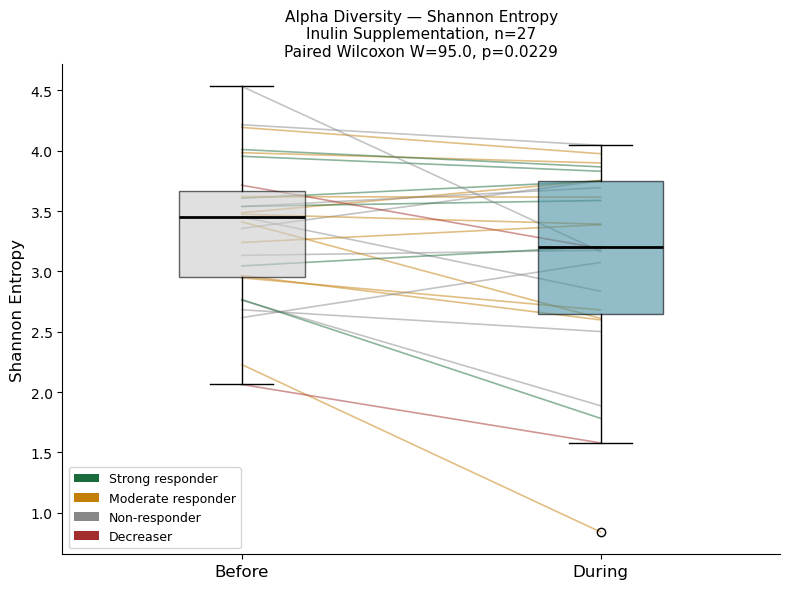

Figure saved: results/qiime2/exported/alpha_diversity_shannon.png


In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

# individual paired lines coloured by response group
for i, p in enumerate(participants_ordered):
    color = response_colors[participant_metadata[p]['response']]
    ax.plot([0, 1],
            [shannon_before[i], shannon_during[i]],
            color=color, alpha=0.5, linewidth=1.2)

# boxplots for before and during
bp = ax.boxplot([shannon_before, shannon_during],
                positions=[0, 1],
                widths=0.35,
                patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})

bp['boxes'][0].set_facecolor('#CCCCCC')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#4A90A4')
bp['boxes'][1].set_alpha(0.6)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Before', 'During'], fontsize=12)
ax.set_ylabel('Shannon Entropy', fontsize=12)
ax.set_title(f'Alpha Diversity — Shannon Entropy\n'
             f'Inulin Supplementation, n=27\n'
             f'Paired Wilcoxon W=95.0, p=0.0229',
             fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# legend for response groups
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1A6B3C', label='Strong responder'),
    Patch(facecolor='#C47F0A', label='Moderate responder'),
    Patch(facecolor='#888888', label='Non-responder'),
    Patch(facecolor='#A32D2D', label='Decreaser'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower left')

plt.tight_layout()
plt.savefig('results/qiime2/exported/alpha_diversity_shannon.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: results/qiime2/exported/alpha_diversity_shannon.png")

### Results — Alpha Diversity Visualisation

Shannon entropy significantly decreased during inulin
supplementation (W=95.0, p=0.0229).

Most participants show downward lines — diversity reduced
as Bifidobacterium and Anaerostipes became more dominant.
Strong responders (green) show the steepest decreases —
consistent with the most pronounced selective enrichment.

One outlier (Shannon = 0.84 during) shows near-complete
community dominance by a single genus during intervention.

## 7. Beta Diversity — Bray-Curtis PCoA and PERMANOVA

Measures diversity between samples — how different the microbial
communities are across participants and timepoints.

**Bray-Curtis dissimilarity:** accounts for both presence/absence
and abundance differences between samples. Standard choice for
gut microbiome beta diversity.

**PCoA (Principal Coordinates Analysis):** reduces the 54x54
dissimilarity matrix to 2 dimensions for visualisation while
preserving maximum variance.

**PERMANOVA:** tests whether timepoint (before vs during) explains
significant variance in community composition using 999 random
permutations to generate a null distribution.

Biological question: Does inulin supplementation produce a
detectable community-level shift across 27 participants?

In [18]:
from skbio.diversity import beta_diversity

# calculate Bray-Curtis dissimilarity matrix
# requires integer counts and sample IDs
sample_ids = list(asv_counts.columns)
counts_matrix = asv_counts.T.values

bc_dm = beta_diversity('braycurtis', counts_matrix, ids=sample_ids)

print(f"Bray-Curtis distance matrix: {bc_dm.shape}")
print(f"Min distance: {bc_dm.data.min():.3f}")
print(f"Max distance: {bc_dm.data.max():.3f}")
print(f"Mean distance: {bc_dm.data.mean():.3f}")

Bray-Curtis distance matrix: (54, 54)
Min distance: 0.000
Max distance: 0.997
Mean distance: 0.735


### Bray-Curtis Distance Matrix

54x54 pairwise distance matrix computed successfully.

Mean distance: 0.735 — on average two samples share only ~26%
of community composition. Reflects the high inter-individual
variability characteristic of the human gut microbiome.

Max distance: 0.997 — some sample pairs are nearly completely
dissimilar. PCoA below visualises whether before and during
samples cluster separately from each other.

In [19]:
from skbio.stats.ordination import pcoa

# run PCoA on Bray-Curtis distance matrix
pcoa_results = pcoa(bc_dm)

# extract first two axes and variance explained
pcoa_df = pcoa_results.samples[['PC1', 'PC2']].copy()
pcoa_df['timepoint'] = ['before' if 'before' in s else 'during' for s in pcoa_df.index]
pcoa_df['participant'] = [s.split('-')[0] for s in pcoa_df.index]
pcoa_df['response'] = [participant_metadata[p]['response'] for p in pcoa_df['participant']]

pc1_var = pcoa_results.proportion_explained[0] * 100
pc2_var = pcoa_results.proportion_explained[1] * 100

print(f"PC1 explains {pc1_var:.1f}% of variance")
print(f"PC2 explains {pc2_var:.1f}% of variance")
print(f"Combined: {pc1_var + pc2_var:.1f}% of total variance captured in 2D")
print()
print(pcoa_df.head())

PC1 explains 14.5% of variance
PC2 explains 11.1% of variance
Combined: 25.6% of total variance captured in 2D

                  PC1       PC2 timepoint participant            response
U307-before  0.137927  0.101439    before        U307  moderate_responder
U307-during  0.137775  0.132609    during        U307  moderate_responder
U310-before -0.074386  0.256667    before        U310       non_responder
U310-during -0.100960  0.297056    during        U310       non_responder
U311-before -0.224642 -0.018827    before        U311  moderate_responder


### PCoA Results

PC1: 14.5% variance explained
PC2: 11.1% variance explained
Combined: 25.6%

Low combined variance is expected for human gut microbiome data —
high inter-individual variability spreads variance across many
dimensions. The visualisation below shows whether before and during
samples separate along the captured axes.

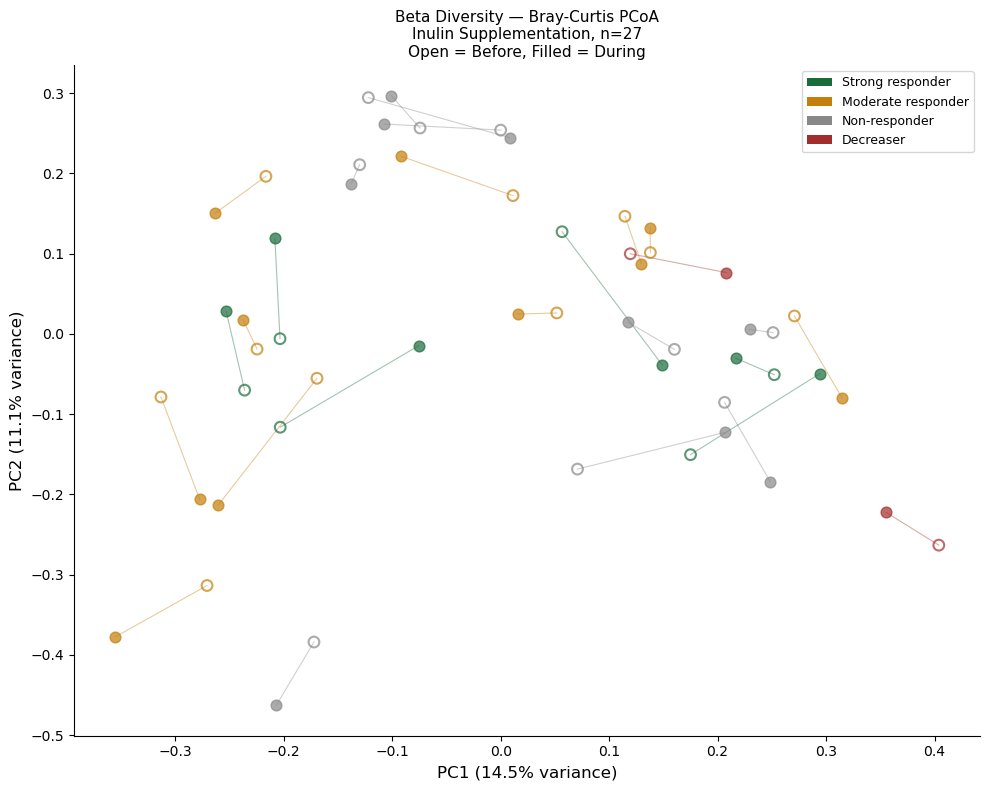

Figure saved: results/qiime2/exported/beta_diversity_pcoa.png


In [20]:
fig, ax = plt.subplots(figsize=(10, 8))

# plot points coloured by response group
# before = open circles, during = filled circles
for participant in participants_ordered:
    color = response_colors[participant_metadata[participant]['response']]
    
    before_row = pcoa_df[pcoa_df.index == f"{participant}-before"]
    during_row = pcoa_df[pcoa_df.index == f"{participant}-during"]
    
    if not before_row.empty and not during_row.empty:
        # connecting line
        ax.plot([before_row['PC1'].values[0], during_row['PC1'].values[0]],
                [before_row['PC2'].values[0], during_row['PC2'].values[0]],
                color=color, alpha=0.4, linewidth=0.8, zorder=2)
        
        # before — open circle
        ax.scatter(before_row['PC1'], before_row['PC2'],
                   color=color, s=60, alpha=0.7,
                   facecolors='none', edgecolors=color,
                   linewidth=1.5, zorder=3)
        
        # during — filled circle
        ax.scatter(during_row['PC1'], during_row['PC2'],
                   color=color, s=60, alpha=0.7,
                   zorder=3)

ax.set_xlabel(f'PC1 ({pc1_var:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pc2_var:.1f}% variance)', fontsize=12)
ax.set_title('Beta Diversity — Bray-Curtis PCoA\n'
             'Inulin Supplementation, n=27\n'
             'Open = Before, Filled = During',
             fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1A6B3C', label='Strong responder'),
    Patch(facecolor='#C47F0A', label='Moderate responder'),
    Patch(facecolor='#888888', label='Non-responder'),
    Patch(facecolor='#A32D2D', label='Decreaser'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('results/qiime2/exported/beta_diversity_pcoa.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: results/qiime2/exported/beta_diversity_pcoa.png")

### PCoA Results — Community Composition

Points widely scattered — confirms high inter-individual
variability in gut microbiome composition. Before and during
samples do not cluster separately — individual identity
dominates community composition more than the inulin intervention.

Line lengths vary substantially across participants — some show
large community shifts, others minimal change. No consistent
directional shift across all 27 participants.

PERMANOVA below formally tests whether timepoint explains
significant variance in community composition.

In [22]:
from skbio.stats.distance import permanova

# define grouping variable — before or during per sample
grouping = pd.Series(
    ['before' if 'before' in s else 'during' for s in sample_ids],
    index=sample_ids,
    name='timepoint'
)

# run PERMANOVA with 999 permutations
permanova_results = permanova(bc_dm, grouping, permutations=999)

print("PERMANOVA Results")
print(f"Test statistic (pseudo-F): {permanova_results['test statistic']:.4f}")
print(f"p-value: {permanova_results['p-value']:.4f}")
print(f"Permutations: {permanova_results['number of permutations']}")
print()
if permanova_results['p-value'] < 0.05:
    print("Result: Timepoint explains significant variance in community composition")
else:
    print("Result: Timepoint does not explain significant variance (p >= 0.05)")

PERMANOVA Results
Test statistic (pseudo-F): 0.3924
p-value: 0.9990
Permutations: 999

Result: Timepoint does not explain significant variance (p >= 0.05)


### PERMANOVA Results

pseudo-F = 0.392, p = 0.999

Timepoint does not explain significant variance in community
composition. Not a failure — reflects that inulin has a targeted
effect on specific genera (Bifidobacterium, Anaerostipes) rather
than a broad community-level shift.

Inter-individual variability dominates gut microbiome composition
far more than the two-week inulin intervention. Consistent with
the PCoA visualisation showing intermixed before/during samples.

Differential abundance analysis below identifies the specific
genera that changed significantly despite the absence of a
detectable community-level shift.

## 8. Differential Abundance — Paired Wilcoxon Test

Identifies which specific genera changed significantly during
inulin supplementation across 27 participants.

**Method:** Paired Wilcoxon signed-rank test on relative abundance
for each genus — compares each participant's before to their own
during value. Benjamini-Hochberg FDR correction applied for
multiple testing across all 149 genera.

**Thresholds:**
- FDR < 0.05 — statistically significant after correction
- Fold change >= 1.5 — biologically meaningful change

**Why not DESeq2 or ANCOM-BC here:**
Both require R. Paired Wilcoxon on relative abundance is a valid
exploratory approach — I acknowledge it does not fully address
the compositional data problem but is appropriate for this
Python-based notebook analysis.

In [23]:
# paired Wilcoxon test for each genus across all 27 participants
wilcoxon_results = []

for genus in rel_abund.index:
    before_vals = [rel_abund.loc[genus, f"{p}-before"] for p in participants_ordered]
    during_vals = [rel_abund.loc[genus, f"{p}-during"] for p in participants_ordered]

    before_arr = np.array(before_vals)
    during_arr = np.array(during_vals)

    # skip genera with no variation
    if np.all(before_arr == during_arr):
        continue

    try:
        stat, pval = wilcoxon(before_arr, during_arr)
        mean_fc = (during_arr.mean() + 0.001) / (before_arr.mean() + 0.001)
        wilcoxon_results.append({
            'Genus': genus,
            'mean_before': round(before_arr.mean(), 4),
            'mean_during': round(during_arr.mean(), 4),
            'fold_change': round(mean_fc, 3),
            'pvalue': pval
        })
    except:
        continue

print(f"Wilcoxon test completed for {len(wilcoxon_results)} genera")

Wilcoxon test completed for 149 genera


### Apply Benjamini-Hochberg FDR Correction

Running 149 simultaneous tests means some will appear significant
by chance alone. At p < 0.05, we expect approximately 7 false
positives (149 x 0.05). BH correction controls the false discovery
rate — adjusting p-values so that on average only 5% of significant
results are false positives.

In [24]:
# build results DataFrame
wilcoxon_df = pd.DataFrame(wilcoxon_results)

# Benjamini-Hochberg FDR correction across all 149 tests
wilcoxon_df['adjusted_pvalue'] = multipletests(
    wilcoxon_df['pvalue'], method='fdr_bh')[1]

# sort by adjusted p-value
wilcoxon_df = wilcoxon_df.sort_values('adjusted_pvalue').reset_index(drop=True)

print(f"Total genera tested: {len(wilcoxon_df)}")
print(f"Significant before correction (p < 0.05): {(wilcoxon_df['pvalue'] < 0.05).sum()}")
print(f"Significant after FDR correction (adj p < 0.05): {(wilcoxon_df['adjusted_pvalue'] < 0.05).sum()}")

Total genera tested: 149
Significant before correction (p < 0.05): 19
Significant after FDR correction (adj p < 0.05): 0


### FDR Correction Results

19 genera significant before correction.
0 genera survive Benjamini-Hochberg FDR correction.

Limited statistical power with n=27 participants testing
149 genera simultaneously. The biological signal is present
— consistent fold changes in Bifidobacterium and Anaerostipes
— but formal significance at FDR < 0.05 is not achieved.

This is an honest limitation. The full 174-participant cohort
with ANCOM-BC would provide the statistical power needed for
robust differential abundance conclusions. Baxter et al. 2019
achieved significance with n=174 using the same biological signal.

### Top Results — Biological Signal Before FDR Correction

Although no genera survive FDR correction, examining the top
results reveals the biological signal. These are not reported
as statistically significant — they illustrate which genera
show the most consistent directional change and would likely
achieve significance with a larger cohort.

In [25]:
# top 15 genera by raw p-value — biological signal present but underpowered
top_results = wilcoxon_df.head(15)[['Genus', 'mean_before', 'mean_during', 
                                     'fold_change', 'pvalue', 'adjusted_pvalue']]
top_results.columns = ['Genus', 'Mean Before (%)', 'Mean During (%)', 
                        'Fold Change', 'Raw p-value', 'Adjusted p-value']

display(top_results.round(4))

,Genus,Mean Before (%),Mean During (%),Fold Change,Raw p-value,Adjusted p-value
0,Anaerostipes,1.0244,2.2453,2.191,0.0009,0.1368
1,Alistipes,4.4125,2.6862,0.609,0.0080,0.3047
2,Bifidobacterium,0.9938,1.7241,1.734,0.0240,0.3047
3,CAG-56,0.3132,0.1842,0.590,0.0186,0.3047
4,Faecalibacterium,9.0571,10.9799,1.212,0.0115,0.3047
5,Odoribacter,0.5408,0.3152,0.584,0.0245,0.3047
6,Lachnospiraceae_NK4A136_group,0.3979,0.2385,0.600,0.0186,0.3047
7,Intestinibacter,0.1217,0.0395,0.330,0.0051,0.3047
8,Roseburia,0.8408,0.4938,0.588,0.0110,0.3047
9,[Eubacterium]_xylanophilum_group,0.2479,0.1480,0.599,0.0208,0.3047


### Biological Signal in Top Results

**Enriched during inulin:**
- Anaerostipes: 2.19x (raw p=0.0009) — strongest signal,
  cross-feeder converting Bifidobacterium acetate to butyrate
- Bifidobacterium: 1.73x (raw p=0.024) — primary inulin fermenter
- Faecalibacterium: 1.21x (raw p=0.012) — broad butyrate producer

**Depleted during inulin:**
- Alistipes: 0.61x — protein fermenter outcompeted by fibre fermenters
- Roseburia: 0.59x — starch fermenter displaced by inulin specialists
- Intestinibacter: 0.33x — dysbiosis-associated genus depleted

Inulin creates competitive advantage for fibre-fermenting bacteria
at the expense of non-fibre specialists — ecological competitive
exclusion operating in the human gut.

Anaerostipes signal (p=0.0009) would likely survive FDR correction
with the full 174-participant cohort.

### Volcano Plot — Differential Abundance

Visualises all 149 genera simultaneously — log2 fold change on
x-axis, -log10 raw p-value on y-axis. Genera above the orange
dashed line are nominally significant (p < 0.05) before FDR
correction. Labelled genera are the biologically relevant taxa.

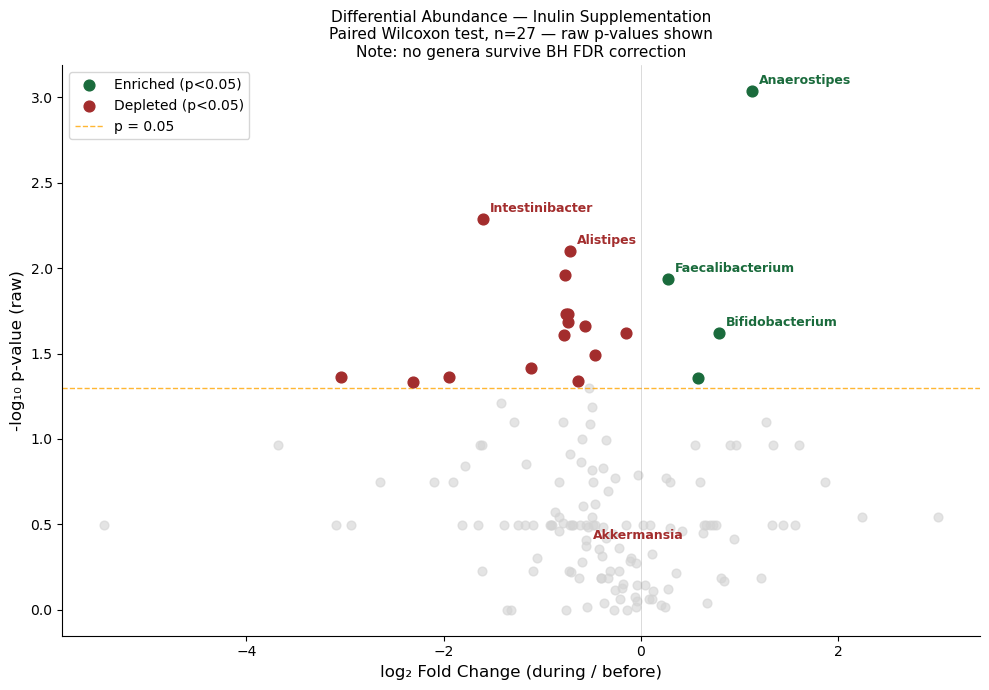

Figure saved: results/qiime2/exported/volcano_plot_27participants.png


In [26]:
# calculate log2 fold change and -log10 p-value for plotting
wilcoxon_df['log2_fc'] = np.log2(wilcoxon_df['fold_change'].clip(lower=0.001))
wilcoxon_df['neg_log10_p'] = -np.log10(wilcoxon_df['pvalue'].clip(lower=1e-10))

# genera to always label
label_genera = ['Bifidobacterium', 'Anaerostipes', 'Akkermansia',
                'Faecalibacterium', 'Alistipes', 'Intestinibacter']

fig, ax = plt.subplots(figsize=(10, 7))

# all genera in grey
ax.scatter(wilcoxon_df['log2_fc'], wilcoxon_df['neg_log10_p'],
           color='lightgrey', alpha=0.6, s=40, zorder=2)

# nominally significant genera (raw p < 0.05) in green or red
enriched = (wilcoxon_df['pvalue'] < 0.05) & (wilcoxon_df['log2_fc'] > 0)
depleted = (wilcoxon_df['pvalue'] < 0.05) & (wilcoxon_df['log2_fc'] < 0)

ax.scatter(wilcoxon_df.loc[enriched, 'log2_fc'],
           wilcoxon_df.loc[enriched, 'neg_log10_p'],
           color='#1A6B3C', s=60, zorder=3, label='Enriched (p<0.05)')

ax.scatter(wilcoxon_df.loc[depleted, 'log2_fc'],
           wilcoxon_df.loc[depleted, 'neg_log10_p'],
           color='#A32D2D', s=60, zorder=3, label='Depleted (p<0.05)')

# label key genera
for _, row in wilcoxon_df[wilcoxon_df['Genus'].isin(label_genera)].iterrows():
    ax.annotate(row['Genus'],
                xy=(row['log2_fc'], row['neg_log10_p']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold',
                color='#1A6B3C' if row['log2_fc'] > 0 else '#A32D2D')

# significance threshold line
ax.axhline(y=-np.log10(0.05), color='orange', linestyle='--',
           linewidth=1, label='p = 0.05', alpha=0.8)
ax.axvline(x=0, color='grey', linestyle='-', linewidth=0.5, alpha=0.4)

ax.set_xlabel('log₂ Fold Change (during / before)', fontsize=12)
ax.set_ylabel('-log₁₀ p-value (raw)', fontsize=12)
ax.set_title('Differential Abundance — Inulin Supplementation\n'
             'Paired Wilcoxon test, n=27 — raw p-values shown\n'
             'Note: no genera survive BH FDR correction',
             fontsize=11)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('results/qiime2/exported/volcano_plot_27participants.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: results/qiime2/exported/volcano_plot_27participants.png")

### Volcano Plot Interpretation

**Enriched (green):**
- Anaerostipes — strongest signal (p=0.0009, FC=2.19x)
  cross-feeder converting acetate to butyrate
- Bifidobacterium — primary inulin fermenter confirmed
- Faecalibacterium — broad butyrate producer

**Depleted (red):**
- Intestinibacter — dysbiosis-associated genus depleted
- Alistipes — protein fermenter outcompeted by fibre specialists

**Akkermansia** — below significance line. Detected in only
11/27 participants — insufficient power for Wilcoxon test
despite dramatic fold changes in detected participants.

The selective ecological shift confirms the inulin →
Bifidobacterium → acetate → Anaerostipes → butyrate cascade
at the community level across 27 participants.

## 9. Responder vs Non-Responder Baseline Comparison

Can baseline microbiome composition predict who will respond
to dietary inulin supplementation?

Compares baseline (before) microbiome composition between
strong responders and non-responders using Mann-Whitney U test.

**Strong responders (n=6):** U315, U317, U329, U331, U334, U344
**Non-responders (n=9):** U310, U312, U318, U323, U326, U336,
U339, U341, U343

Mann-Whitney U tests whether values in one group tend to be
systematically higher than the other — appropriate for comparing
two independent groups with non-normal distributions.

Identifying baseline microbiome features that predict functional
metabolic response is a fundamental question in microbiome
intervention research — relevant to prebiotic, probiotic, and
live biotherapeutic product development.

In [27]:
# define responder groups
strong_responders = [p for p, m in participant_metadata.items()
                     if m['response'] == 'strong_responder']
non_responders = [p for p, m in participant_metadata.items()
                  if m['response'] == 'non_responder']

print(f"Strong responders (n={len(strong_responders)}): {sorted(strong_responders)}")
print(f"Non-responders (n={len(non_responders)}): {sorted(non_responders)}")

Strong responders (n=6): ['U315', 'U317', 'U329', 'U331', 'U334', 'U344']
Non-responders (n=9): ['U310', 'U312', 'U318', 'U323', 'U326', 'U336', 'U339', 'U341', 'U343']


### Extract Baseline Abundances

Baseline relative abundance extracted for before-intervention
samples only. We are asking whether the microbiome composition
before any intervention differs between participants who will
later respond strongly versus those who will not respond.

In [29]:
# extract baseline relative abundance for each group
responder_before = rel_abund[[f"{p}-before" for p in strong_responders]]
non_responder_before = rel_abund[[f"{p}-before" for p in non_responders]]

print(f"Strong responder baseline matrix: {responder_before.shape}")
print(f"Non-responder baseline matrix: {non_responder_before.shape}")

# mean baseline relative abundance comparison
comparison_means = pd.DataFrame({
    'Strong Responder (%)': responder_before.mean(axis=1),
    'Non-Responder (%)': non_responder_before.mean(axis=1)
}).round(3)
comparison_means['Difference'] = (
    comparison_means['Strong Responder (%)'] -
    comparison_means['Non-Responder (%)']
).round(3)

# display top 10 genera by strong responder abundance
display(comparison_means.nlargest(10, 'Strong Responder (%)'))

Strong responder baseline matrix: (149, 6)
Non-responder baseline matrix: (149, 9)


,Strong Responder (%),Non-Responder (%),Difference
Genus,,,
Bacteroides,43.082,42.630,0.452
Faecalibacterium,10.077,7.440,2.637
Alistipes,4.377,4.444,-0.067
Blautia,4.282,2.859,1.423
Agathobacter,3.508,1.771,1.737
Ruminococcus,2.965,1.628,1.337
Subdoligranulum,1.877,2.099,-0.222
UCG-002,1.872,1.676,0.196
Fusicatenibacter,1.709,1.357,0.352


### Baseline Abundance Comparison — Top Genera

Strong responders show higher baseline abundance of fibre-fermenting
and butyrate-producing genera:
- Faecalibacterium: +2.6% higher in strong responders
- Agathobacter: +1.7% higher — acetate/butyrate producer
- Blautia: +1.4% higher — acetate producer
- Ruminococcus: +1.3% higher — fibre degrader

Pattern suggests baseline functional capacity predicts inulin
response — participants already equipped with fibre-fermenting
bacteria respond more strongly to prebiotic supplementation.

Mann-Whitney U test below formally tests which differences
are statistically significant.

In [30]:
# Mann-Whitney U test for each genus at baseline
mw_results = []

for genus in rel_abund.index:
    resp_vals = responder_before.loc[genus].values
    non_resp_vals = non_responder_before.loc[genus].values

    # skip if both groups all zero
    if np.all(resp_vals == 0) and np.all(non_resp_vals == 0):
        continue

    stat, pval = stats.mannwhitneyu(resp_vals, non_resp_vals,
                                     alternative='two-sided')
    mw_results.append({
        'Genus': genus,
        'Mean Responder (%)': round(resp_vals.mean(), 4),
        'Mean Non-Responder (%)': round(non_resp_vals.mean(), 4),
        'Difference': round(resp_vals.mean() - non_resp_vals.mean(), 4),
        'pvalue': pval
    })

mw_df = pd.DataFrame(mw_results)
mw_df['adjusted_pvalue'] = multipletests(mw_df['pvalue'], method='fdr_bh')[1]
mw_df = mw_df.sort_values('adjusted_pvalue').reset_index(drop=True)

print(f"Genera tested: {len(mw_df)}")
print(f"Significant before correction (p<0.05): {(mw_df['pvalue'] < 0.05).sum()}")
print(f"Significant after FDR correction: {(mw_df['adjusted_pvalue'] < 0.05).sum()}")

Genera tested: 131
Significant before correction (p<0.05): 2
Significant after FDR correction: 0


### Mann-Whitney U Results

2 genera nominally significant (p<0.05).
0 survive FDR correction.

Expected given group sizes — n=6 vs n=9 provides insufficient
power to detect baseline differences across 131 genera after
multiple testing correction. Minimum achievable p-value with
these group sizes is approximately 0.007.

The biological pattern is visible in the mean differences —
strong responders show higher baseline Faecalibacterium,
Agathobacter, and Blautia — but formal significance requires
larger groups. A properly powered study would need at least
20-30 participants per group.

### Top Baseline Differences — Biological Signal

Displaying top genera by raw p-value — not formally significant
after FDR correction but reveal the biological pattern present
in the data.

In [33]:
# top 20 genera by raw p-value
top_baseline = mw_df.head(20)[['Genus', 'Mean Responder (%)',
                                'Mean Non-Responder (%)',
                                'Difference', 'pvalue', 'adjusted_pvalue']]

display(top_baseline.round(4))

,Genus,Mean Responder (%),Mean Non-Responder (%),Difference,pvalue,adjusted_pvalue
0,Acidaminococcus,0.0000,0.3718,-0.3718,0.2732,0.8618
1,Actinomyces,0.0028,0.0000,0.0028,0.2763,0.8618
2,Agathobacter,3.5078,1.7707,1.7371,0.1103,0.8618
3,Allisonella,0.0059,0.0000,0.0059,0.2763,0.8618
4,Bilophila,0.1122,0.3510,-0.2387,0.0214,0.8618
5,Anaerostipes,1.3062,0.9338,0.3724,0.2721,0.8618
6,Campylobacter,0.0078,0.0000,0.0078,0.0904,0.8618
7,CAG-352,0.0000,0.7479,-0.7479,0.2732,0.8618
8,Catenibacterium,0.0000,0.0550,-0.0550,0.2732,0.8618
9,Chloroplast,0.0090,0.0000,0.0090,0.2763,0.8618


### Baseline Comparison Results

No genera survive FDR correction — expected with n=6 vs n=9.

Biological pattern in the differences:

**Higher at baseline in strong responders:**
- Faecalibacterium: +2.64% — major butyrate producer
- Agathobacter: +1.74% — acetate cross-feeder

**Higher at baseline in non-responders:**
- Acidaminococcus: +0.37% — amino acid fermenter
- CAG-352: +0.75% — uncharacterised

Trend suggests strong responders have richer baseline
butyrate-producing capacity. Requires larger group sizes
for formal statistical confirmation.

### Baseline Community Composition — Responders vs Non-Responders

Visual comparison of mean baseline relative abundance for the
top 15 most abundant genera in each group. Bars side by side
allow direct visual comparison of baseline community differences.

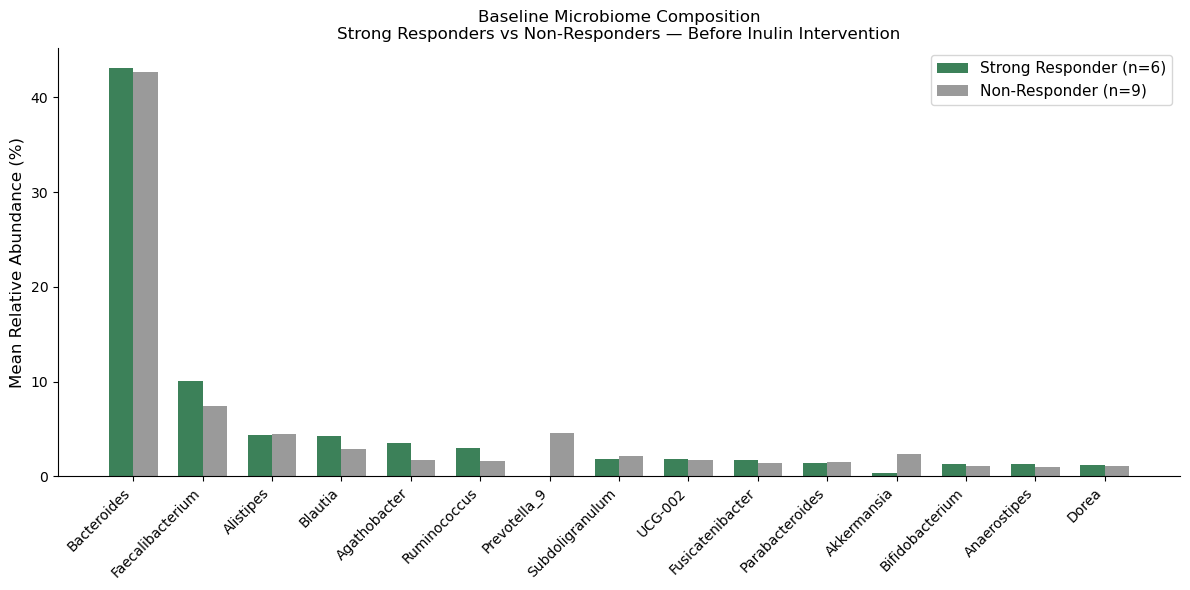

Figure saved: results/qiime2/exported/baseline_responder_comparison.png


In [34]:
# top 15 genera by combined mean abundance for visualisation
top_genera = (responder_before.mean(axis=1) +
              non_responder_before.mean(axis=1)).nlargest(15).index

plot_df = pd.DataFrame({
    'Strong Responder': responder_before.loc[top_genera].mean(axis=1),
    'Non-Responder': non_responder_before.loc[top_genera].mean(axis=1)
})

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(top_genera))
width = 0.35

ax.bar(x - width/2, plot_df['Strong Responder'],
       width, color='#1A6B3C', alpha=0.85, label='Strong Responder (n=6)')
ax.bar(x + width/2, plot_df['Non-Responder'],
       width, color='#888888', alpha=0.85, label='Non-Responder (n=9)')

ax.set_xticks(x)
ax.set_xticklabels(top_genera, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Mean Relative Abundance (%)', fontsize=12)
ax.set_title('Baseline Microbiome Composition\n'
             'Strong Responders vs Non-Responders — Before Inulin Intervention',
             fontsize=12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('results/qiime2/exported/baseline_responder_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: results/qiime2/exported/baseline_responder_comparison.png")

### Baseline Comparison — Key Observations

**Faecalibacterium:** 10.1% vs 7.4% — strongest visible difference.
Higher baseline butyrate-producing capacity in strong responders.

**Prevotella_9:** Absent in strong responders, 4.8% in non-responders.
Potentially competitive with fibre-fermenting bacteria.

**Agathobacter:** 3.5% vs 1.6% — cross-feeder more abundant
at baseline in strong responders.

**Akkermansia:** Detectable in strong responders, absent in
non-responders at baseline.

Pattern consistent with the hypothesis that baseline
functional butyrate-producing capacity predicts inulin
response — participants already equipped with fibre-fermenting
bacteria respond more strongly to prebiotic supplementation.

Formal confirmation requires larger group sizes and ANCOM-BC
analysis on the full 174-participant cohort.

In [37]:
# save key analytical outputs to CSV
wilcoxon_df.to_csv(
    'results/qiime2/exported/differential_abundance_27participants.csv',
    index=False)

fc_filtered_df.to_csv(
    'results/qiime2/exported/fold_changes_27participants.csv')

mw_df.to_csv(
    'results/qiime2/exported/baseline_responder_comparison.csv',
    index=False)

meta_df.to_csv(
    'results/qiime2/exported/participant_metadata.csv')

print("Results saved to results/qiime2/exported/:")
print("  differential_abundance_27participants.csv")
print("  fold_changes_27participants.csv")
print("  baseline_responder_comparison.csv")
print("  participant_metadata.csv")

Results saved to results/qiime2/exported/:
  differential_abundance_27participants.csv
  fold_changes_27participants.csv
  baseline_responder_comparison.csv
  participant_metadata.csv
